In [9]:
import requests
import pandas as pd

import plotly.express as px
import folium

import os
from pathlib import Path
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError
from zipfile import ZipFile
import geopandas as gpd
from urllib.parse import urlencode

In [12]:
citibike_df = pd.read_csv("../data/citibike/JC/JC2025_Enriched.csv")

Geopandas

In [13]:
url = 'https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/citibike/JC/jersey-city-neighborhoods.geojson'

jersey_city = gpd.read_file(url)

jersey_city.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


In [14]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cartodb_id    53 non-null     int32   
 1   area_sq_ft    53 non-null     float64 
 2   acres         53 non-null     float64 
 3   area          53 non-null     str     
 4   neighborhood  53 non-null     str     
 5   color         18 non-null     float64 
 6   lon           53 non-null     float64 
 7   lat           53 non-null     float64 
 8   geometry      53 non-null     geometry
dtypes: float64(5), geometry(1), int32(1), str(2)
memory usage: 4.8 KB


In [15]:
jersey_city.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [16]:
jersey_city = jersey_city.to_crs("EPSG:4326")

<Axes: >

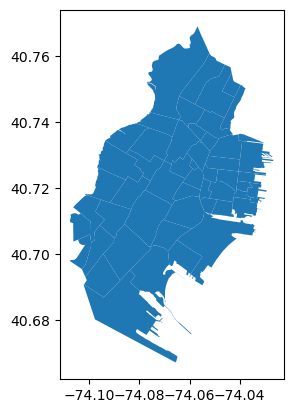

In [17]:
jersey_city.plot()

Station Level Summary

In [18]:
start_stations = citibike_df[
    [
        "ride_id",
        "start_station_id",
        "start_station_name",
        "start_lat",
        "start_lng"
    ]
].copy()

In [19]:
start_stations.rename(columns= {"start_station_id":'station_id',
        "start_station_name":'station_name',
        "start_lat": 'lat',
        "start_lng": 'lng'},
        inplace=True
                      )

start_stations["activity_type"] = "departure"

start_stations.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,880A0159BA5275FB,JC019,Hilltop,40.731169,-74.057574,departure
1,1A5E1E274B2AF0AD,JC019,Hilltop,40.731169,-74.057574,departure
2,EA9928D3C05B8377,JC019,Hilltop,40.731169,-74.057574,departure
3,3C42C367750B9292,JC019,Hilltop,40.731169,-74.057574,departure
4,94D3B0265A7BDE1F,JC019,Hilltop,40.731169,-74.057574,departure


Arrivals

In [20]:
end_stations = citibike_df[
    [
        "ride_id",
        "end_station_id",
        "end_station_name",
        "end_lat",
        "end_lng"
    ]
].copy()

end_stations = end_stations.rename(
    columns={
        "end_station_id": "station_id",
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lng": "lng"
    }
)

end_stations["activity_type"] = "arrival"

end_stations.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,880A0159BA5275FB,JC024,Pershing Field,40.742677,-74.051789,arrival
1,1A5E1E274B2AF0AD,JC063,Jackson Square,40.711130,-74.078900,arrival
2,EA9928D3C05B8377,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,arrival
3,3C42C367750B9292,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,arrival
4,94D3B0265A7BDE1F,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,arrival


Concatenate Departures and Arrivals

In [21]:
station_activity_long = pd.concat(
    [
        start_stations,
        end_stations
    ],
    ignore_index=True
)

station_activity_long = station_activity_long.dropna(
    subset=[
        "station_id",
        "station_name",
        "lat",
        "lng"
    ]
)

station_activity_long.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,880A0159BA5275FB,JC019,Hilltop,40.731169,-74.057574,departure
1,1A5E1E274B2AF0AD,JC019,Hilltop,40.731169,-74.057574,departure
2,EA9928D3C05B8377,JC019,Hilltop,40.731169,-74.057574,departure
3,3C42C367750B9292,JC019,Hilltop,40.731169,-74.057574,departure
4,94D3B0265A7BDE1F,JC019,Hilltop,40.731169,-74.057574,departure


Cleaning and Aggregating

In [22]:
station_activity_agg = (
    station_activity_long
    .groupby(
        [
            "station_id",
            "station_name",
            "lat",
            "lng",
            "activity_type"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
)

station_activity_agg.head()

,station_id,station_name,lat,lng,activity_type,number_of_rides
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,arrival,1
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,arrival,1
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,arrival,1
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,arrival,1
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,arrival,1


Pivot the Data
Pivot to One Row per Station

In [23]:
station_summary = (station_activity_agg.pivot_table(
        index=[
            "station_id",
            "station_name",
            "lat",
            "lng"
        ],
        columns="activity_type",
        values="number_of_rides",
        fill_value=0
    )
    .reset_index()
)

station_summary.head()

activity_type,station_id,station_name,lat,lng,arrival,departure
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,1.0,0.0
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,1.0,0.0
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,1.0,0.0
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,1.0,0.0
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,1.0,0.0


In [24]:
station_summary = station_summary.rename(
    columns={
        "departure": "total_departures",
        "arrival": "total_arrivals"
    }
)

station_summary["total_activity"] = (
    station_summary["total_departures"] +
    station_summary["total_arrivals"]
)

station_summary["net_departures"] = (
    station_summary["total_departures"] -
    station_summary["total_arrivals"]
)

station_summary = station_summary.sort_values(
    "total_activity",
    ascending=False
).reset_index(drop=True)

station_summary.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,45004.0,92748.0,-2740.0
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25889.0,52527.0,-749.0
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22259.0,44606.0,-88.0
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20663.0,41361.0,-35.0


In [26]:
station_gdf = gpd.GeoDataFrame(
    station_summary,
    geometry=gpd.points_from_xy(
        station_summary["lng"],
        station_summary["lat"]
    ),
    crs="EPSG:4326"
)

station_gdf.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures,geometry
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,45004.0,92748.0,-2740.0,POINT (-74.04309 40.71941)
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25889.0,52527.0,-749.0,POINT (-74.0303 40.73594)
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22259.0,44606.0,-88.0,POINT (-74.04425 40.7276)
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0,POINT (-74.02901 40.73672)
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20663.0,41361.0,-35.0,POINT (-74.03376 40.72722)


In [27]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how="inner",
    predicate="within"
)

station_neighborhood.head()

,station_id,station_name,lat_left,lng,total_arrivals,total_departures,total_activity,net_departures,geometry,index_right,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat_right
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,45004.0,92748.0,-2740.0,POINT (-74.04309 40.71941),49,2,411601381.8,9449.068,Downtown,Van Vorst Park,21.0,-74.047234,40.718943
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22259.0,44606.0,-88.0,POINT (-74.04425 40.7276),10,18,411601381.8,9449.068,Downtown,Hamilton Park,28.0,-74.046672,40.727436
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20663.0,41361.0,-35.0,POINT (-74.03376 40.72722),8,12,411601381.8,9449.068,Downtown,Newport,22.0,-74.034927,40.729255
5,JC109,Bergen Ave & Sip Ave,40.731009,-74.064437,20357.0,20398.0,40755.0,41.0,POINT (-74.06444 40.73101),16,31,411601381.8,9449.068,Journal Square,Journal Square,NaN,-74.063466,40.733757
6,JC116,Exchange Pl,40.716366,-74.034344,20142.0,20008.0,40150.0,-134.0,POINT (-74.03434 40.71637),48,13,411601381.8,9449.068,Downtown,Exchange Place,23.0,-74.033539,40.716458


Create Route-Level Summary

In [28]:
route_summary = (
    citibike_df
    .dropna(
        subset=[
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ]
    )
    .groupby(
        [
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
    .sort_values("number_of_rides", ascending=False)
)

route_summary["route"] = (
    route_summary["start_station_name"] +
    " → " +
    route_summary["end_station_name"]
)

route_summary.head()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides,route
83,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,4559,Hoboken Terminal - Hudson St & Hudson Pl → Hob...
5583,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,4306,McGinley Square → Bergen Ave & Sip Ave
8709,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,4131,Grove St PATH → Marin Light Rail
3937,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,3831,Marin Light Rail → Grove St PATH
8723,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,3750,Grove St PATH → Liberty Light Rail


Inspect Top Routes

In [29]:
top_routes = route_summary.head(20)

top_routes[
    [
        "route",
        "number_of_rides"
    ]
]

,route,number_of_rides
83,Hoboken Terminal - Hudson St & Hudson Pl → Hob...,4559
5583,McGinley Square → Bergen Ave & Sip Ave,4306
8709,Grove St PATH → Marin Light Rail,4131
3937,Marin Light Rail → Grove St PATH,3831
8723,Grove St PATH → Liberty Light Rail,3750
8445,Bergen Ave & Sip Ave → McGinley Square,3609
5395,Liberty Light Rail → Grove St PATH,3605
8154,Hoboken Ave at Monmouth St → Hoboken Terminal ...,3257
4570,Brunswick St → Grove St PATH,3175
3788,Hamilton Park → Grove St PATH,2998


Drawing Top Lines with Folium

In [30]:
import folium

top_lines = route_summary.head(100).copy()

center_lat = station_gdf["lat"].mean()
center_lng = station_gdf["lng"].mean()

line_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

max_rides = top_lines["number_of_rides"].max()

for _, row in top_lines.iterrows():

    start_point = [
        row["start_lat"],
        row["start_lng"]
    ]

    end_point = [
        row["end_lat"],
        row["end_lng"]
    ]

    line_weight = 1 + (row["number_of_rides"] / max_rides) * 8

    folium.PolyLine(
        locations=[start_point, end_point],
        weight=line_weight,
        opacity=0.5,
        popup=f"""
        <b>{row['route']}</b><br>
        Number of Rides: {row['number_of_rides']}
        """
    ).add_to(line_map)

line_map

In [31]:
print("Station CRS:", station_gdf.crs)
print("Neighborhood CRS:", jersey_city.crs)

Station CRS: EPSG:4326
Neighborhood CRS: EPSG:4326


In [33]:
station_gdf = station_gdf.to_crs("EPSG:4326")
jersey_city = jersey_city.to_crs("EPSG:4326")

In [34]:
jersey_city.columns

Index(['cartodb_id', 'area_sq_ft', 'acres', 'area', 'neighborhood', 'color',
       'lon', 'lat', 'geometry'],
      dtype='str')

In [35]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how="inner",
    predicate="within"
)

station_neighborhood.head()

,station_id,station_name,lat_left,lng,total_arrivals,total_departures,total_activity,net_departures,geometry,index_right,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat_right
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,45004.0,92748.0,-2740.0,POINT (-74.04309 40.71941),49,2,411601381.8,9449.068,Downtown,Van Vorst Park,21.0,-74.047234,40.718943
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22259.0,44606.0,-88.0,POINT (-74.04425 40.7276),10,18,411601381.8,9449.068,Downtown,Hamilton Park,28.0,-74.046672,40.727436
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20663.0,41361.0,-35.0,POINT (-74.03376 40.72722),8,12,411601381.8,9449.068,Downtown,Newport,22.0,-74.034927,40.729255
5,JC109,Bergen Ave & Sip Ave,40.731009,-74.064437,20357.0,20398.0,40755.0,41.0,POINT (-74.06444 40.73101),16,31,411601381.8,9449.068,Journal Square,Journal Square,NaN,-74.063466,40.733757
6,JC116,Exchange Pl,40.716366,-74.034344,20142.0,20008.0,40150.0,-134.0,POINT (-74.03434 40.71637),48,13,411601381.8,9449.068,Downtown,Exchange Place,23.0,-74.033539,40.716458


In [36]:
print(station_gdf.shape)
print(station_neighborhood.shape)

(488, 9)
(79, 18)


Check How Many Stations Are Inside Jersey City

In [37]:
print("All stations:", len(station_gdf))
print("Stations inside Jersey City neighborhoods:", len(station_neighborhood))

All stations: 488
Stations inside Jersey City neighborhoods: 79


Neighborhood-Level Summary
Aggregate station activity by neighborhood

In [38]:
neighborhood_activity = (
    station_neighborhood
    .groupby('neighborhood', as_index=False)
    .agg(
        number_of_stations=("station_id", "nunique"),
        total_departures=("total_departures", "sum"),
        total_arrivals=("total_arrivals", "sum"),
        total_activity=("total_activity", "sum"),
        net_departures=("net_departures", "sum")
    )
)

neighborhood_activity["avg_activity_per_station"] = (
    neighborhood_activity["total_activity"] /
    neighborhood_activity["number_of_stations"]
)

neighborhood_activity = neighborhood_activity.sort_values(
    "total_activity",
    ascending=False
)

neighborhood_activity.head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
25,Van Vorst Park,6,96210.0,98853.0,195063.0,-2643.0,32510.500000
17,Palus Hook,6,59567.0,59160.0,118727.0,407.0,19787.833333
14,Newport,2,39383.0,39402.0,78785.0,-19.0,39392.500000
10,Journal Square,3,33007.0,32560.0,65567.0,447.0,21855.666667
4,Hamilton Park,2,31762.0,31922.0,63684.0,-160.0,31842.000000


Create Center Point for the Map

In [39]:
center_lat = station_gdf.geometry.y.mean()
center_lng = station_gdf.geometry.x.mean()

center_lat, center_lng

(np.float64(40.734012258630905), np.float64(-74.00137516113631))

Visualize Each Station as a Point

In [40]:
station_point_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

for _, row in station_gdf.iterrows():

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=5,
        popup=f"""
        <b>{row['station_name']}</b><br>
        Station ID: {row['station_id']}<br>
        Departures: {row['total_departures']:.0f}<br>
        Arrivals: {row['total_arrivals']:.0f}<br>
        Total Activity: {row['total_activity']:.0f}<br>
        Net Departures: {row['net_departures']:.0f}
        """,
        tooltip=row["station_name"],
        fill=True,
        fill_opacity=0.6,
        opacity=0.8
    ).add_to(station_point_map)

station_point_map

Merge Neighborhood Metrics Back to Polygons

In [41]:
neighborhood_choropleth_gdf = jersey_city.merge(
    neighborhood_activity,
    on='neighborhood',
    how="left"
)

neighborhood_choropleth_gdf.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696...",1.0,12.0,9.0,21.0,3.0,21.000
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700...",NaN,NaN,NaN,NaN,NaN,NaN
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737...",NaN,NaN,NaN,NaN,NaN,NaN
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ...",6.0,30896.0,30730.0,61626.0,166.0,10271.000
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020...",16.0,6173.0,6045.0,12218.0,128.0,763.625


Replace missing values with zero

In [42]:
activity_columns = [
    "number_of_stations",
    "total_departures",
    "total_arrivals",
    "total_activity",
    "net_departures",
    "avg_activity_per_station"
]

neighborhood_choropleth_gdf[activity_columns] = (
    neighborhood_choropleth_gdf[activity_columns]
    .fillna(0)
)

neighborhood_choropleth_gdf[
    [
        'neighborhood',
        "number_of_stations",
        "total_departures",
        "total_arrivals",
        "total_activity",
        "avg_activity_per_station"
    ]
].head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,avg_activity_per_station
0,Port Liberte,1.0,12.0,9.0,21.0,21.000
1,LSP Industrial,0.0,0.0,0.0,0.0,0.000
2,Hackensack,0.0,0.0,0.0,0.0,0.000
3,Lafayette,6.0,30896.0,30730.0,61626.0,10271.000
4,Jackson Hill,16.0,6173.0,6045.0,12218.0,763.625


Helper Function for Folium Choropleth

In [43]:
def create_neighborhood_choropleth(
    gdf,
    metric,
    legend_name,
    neighborhood_col="neighborhood"
):
    choropleth_map = folium.Map(
        location=[center_lat, center_lng],
        zoom_start=12
    )

    folium.Choropleth(
        geo_data=gdf,
        data=gdf,
        columns=[neighborhood_col, metric],
        key_on=f"feature.properties.{neighborhood_col}",
        fill_opacity=0.7,
        line_opacity=0.4,
        legend_name=legend_name,
        nan_fill_opacity=0.1
    ).add_to(choropleth_map)

    folium.GeoJson(
        gdf,
        name="Neighborhood Boundaries",
        tooltip=folium.GeoJsonTooltip(
            fields=[
                neighborhood_col,
                metric
            ],
            aliases=[
                "Neighborhood:",
                f"{legend_name}:"
            ],
            localize=True
        ),
        style_function=lambda feature: {
            "fillOpacity": 0,
            "color": "black",
            "weight": 1
        }
    ).add_to(choropleth_map)

    folium.LayerControl().add_to(choropleth_map)

    return choropleth_map

Choropleth: Total Activity by Neighborhood

In [44]:
total_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_activity",
    legend_name="Total Citi Bike Activity",
    neighborhood_col="neighborhood"
)

total_activity_map

Number of Stations

In [45]:
station_count_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="number_of_stations",
    legend_name="Number of Citi Bike Stations",
    neighborhood_col="neighborhood"
)

station_count_map

Average Activity per Station

In [46]:
avg_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="avg_activity_per_station",
    legend_name="Average Activity per Station",
    neighborhood_col="neighborhood"
)

avg_activity_map

Total Departures

In [47]:
departures_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_departures",
    legend_name="Total Departures",
    neighborhood_col="neighborhood"
)

departures_map

Total Arrivals

In [48]:
arrivals_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_arrivals",
    legend_name="Total Arrivals",
    neighborhood_col="neighborhood"
)

arrivals_map